In [1]:
import os
import pandas as pd
from sqlalchemy import create_engine, text
from dotenv import load_dotenv
import seaborn as sns
import matplotlib.pyplot as plt

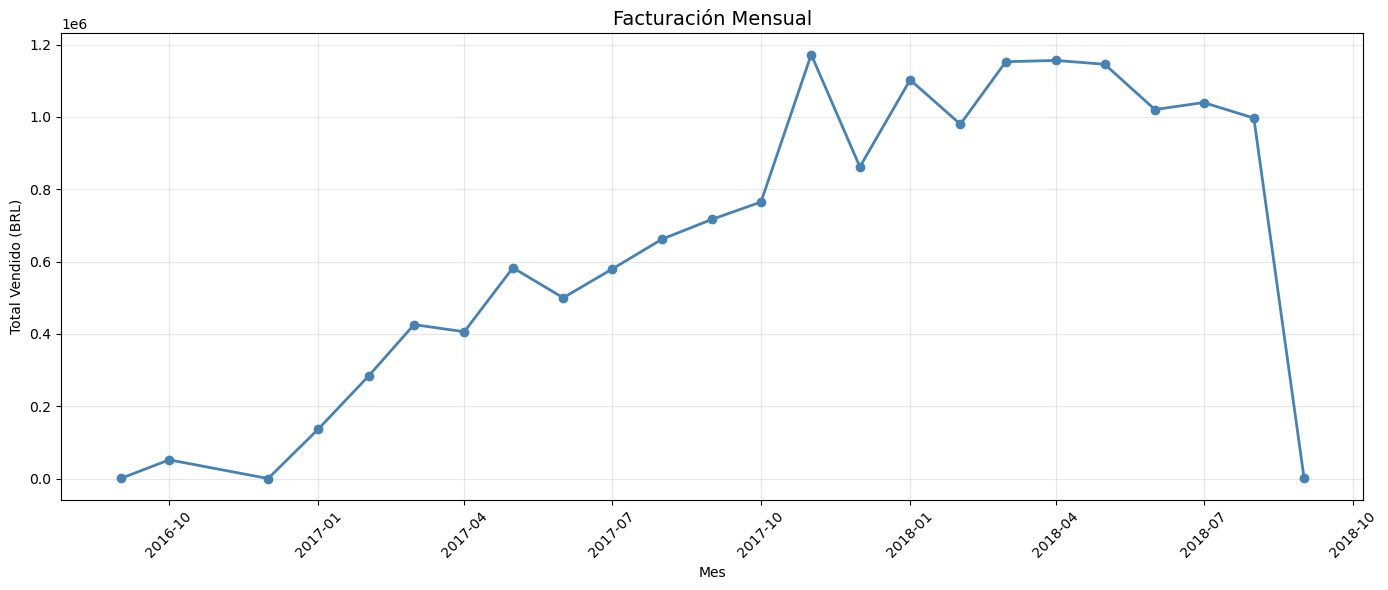

,mes_venta,total_vendido
0,2016-09-01,136.23
1,2016-10-01,51657.53
2,2016-12-01,19.62
3,2017-01-01,137006.76
4,2017-02-01,283621.94
5,2017-03-01,425656.40
6,2017-04-01,405988.38
7,2017-05-01,582926.16
8,2017-06-01,499827.47
9,2017-07-01,578858.58


In [16]:
# Conexión 
load_dotenv()
engine = create_engine(f"mysql+pymysql://{os.getenv('DB_USER')}:{os.getenv('DB_PASSWORD')}@{os.getenv('DB_HOST')}/{os.getenv('DB_NAME')}")

# Función para leer archivo .sql y devolver un DataFrame
def ejecutar_query_desde_archivo(ruta_archivo):
    with open(ruta_archivo, 'r', encoding='utf-8') as archivo:
        query_sql = archivo.read()
    
    with engine.connect() as conexion:
        # read_sql ejecuta la consulta y arma el DataFrame
        df = pd.read_sql(text(query_sql), con=conexion)
    return df

df_facturacion = ejecutar_query_desde_archivo('queries/01_facturacion_mensual.sql')
# Convertir mes_venta a datetime para mejor visualización
df_facturacion['mes_venta'] = pd.to_datetime(df_facturacion['mes_venta'])

# Crear gráfico de línea para tendencia de facturación mensual
plt.figure(figsize=(14, 6))
plt.plot(df_facturacion['mes_venta'], df_facturacion['total_vendido'], marker='o', linewidth=2, color='steelblue')
plt.title('Facturación Mensual', fontsize=14)
plt.xlabel('Mes')
plt.ylabel('Total Vendido')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
# Ver el resultado exacto
df_facturacion

In [3]:
df_gasto = ejecutar_query_desde_archivo('queries/02_gasto_promedio.sql')

df_gasto

,gasto_promedio_por_compra
0,160.990267


/tmp/ipykernel_7349/2948912705.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='metodo_de_pago', y='cantidad_transacciones', data=df_plot, ax=ax_left, palette='viridis')
/tmp/ipykernel_7349/2948912705.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax_left.set_xticklabels(ax_left.get_xticklabels(), rotation=45, ha='right')


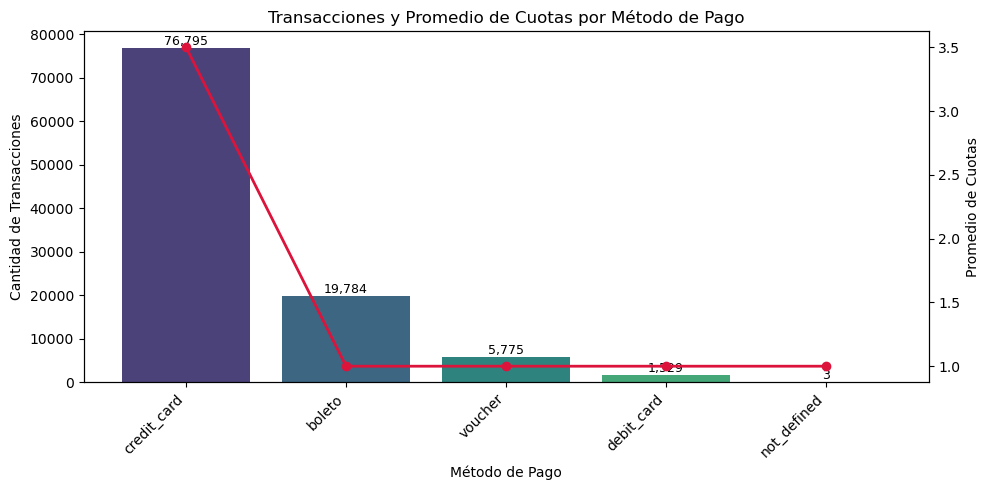

,metodo_de_pago,cantidad_transacciones,promedio_cuotas
0,credit_card,76795,3.5
1,boleto,19784,1.0
2,voucher,5775,1.0
3,debit_card,1529,1.0
4,not_defined,3,1.0


In [17]:
df_metodo_cuotas = ejecutar_query_desde_archivo('queries/03_metodo_cuotas.sql')

df_plot = df_metodo_cuotas.sort_values('cantidad_transacciones', ascending=False)

fig2, ax_left = plt.subplots(figsize=(10, 5))
sns.barplot(x='metodo_de_pago', y='cantidad_transacciones', data=df_plot, ax=ax_left, palette='viridis')
ax_left.set_xlabel('Método de Pago')
ax_left.set_ylabel('Cantidad de Transacciones')
ax_left.set_title('Transacciones y Promedio de Cuotas por Método de Pago')
ax_left.set_xticklabels(ax_left.get_xticklabels(), rotation=45, ha='right')

ax_right = ax_left.twinx()
ax_right.plot(df_plot['metodo_de_pago'], df_plot['promedio_cuotas'], color='crimson', marker='o', linewidth=2)
ax_right.set_ylabel('Promedio de Cuotas')

for p in ax_left.patches:
    ax_left.annotate(f'{int(p.get_height()):,}', (p.get_x() + p.get_width() / 2, p.get_height()), 
                     ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()
df_metodo_cuotas

/tmp/ipykernel_7349/4253360793.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='estado', y='total_facturado', data=df_estados_mas_facturan, palette='coolwarm')


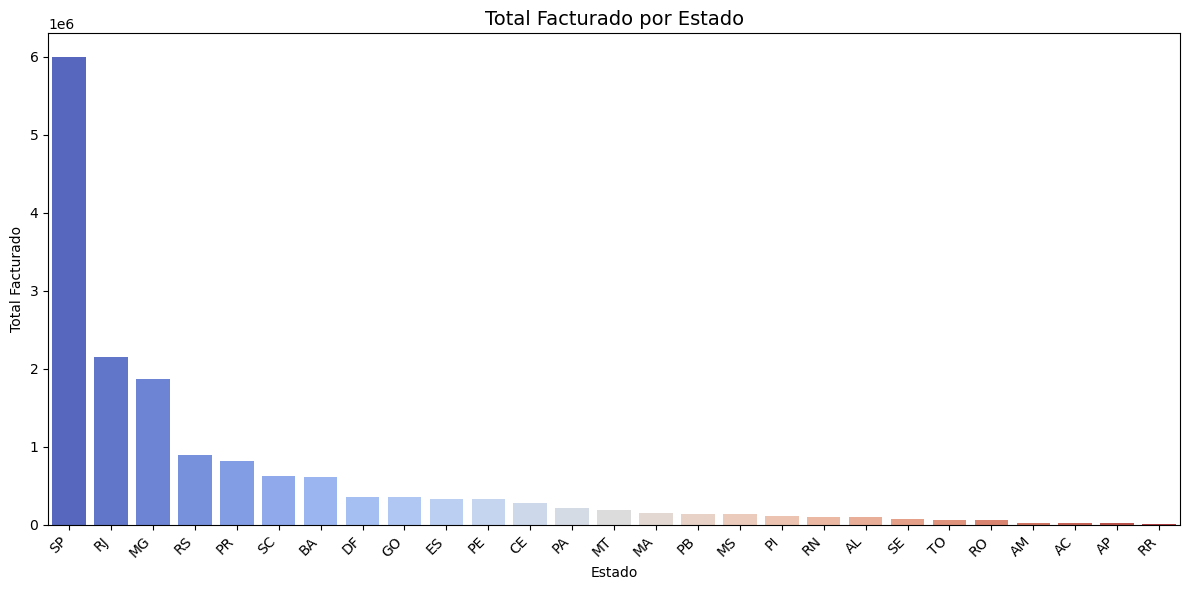

,estado,total_facturado
0,SP,5998226.96
1,RJ,2144379.69
2,MG,1872257.26
3,RS,890898.54
4,PR,811156.38
5,SC,623086.43
6,BA,616645.82
7,DF,355141.08
8,GO,350092.31
9,ES,325967.55


In [20]:
df_estados_mas_facturan = ejecutar_query_desde_archivo('queries/04_estados_mas_facturan.sql')
plt.figure(figsize=(12, 6))
sns.barplot(x='estado', y='total_facturado', data=df_estados_mas_facturan, palette='coolwarm')
plt.title('Total Facturado por Estado', fontsize=14)
plt.xlabel('Estado')
plt.ylabel('Total Facturado')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()
df_estados_mas_facturan.head(10)

=== Top 10 categorías más vendidas ===
            categoria unidades_vendidas
       bed_bath_table            11,115
        health_beauty             9,670
       sports_leisure             8,641
      furniture_decor             8,334
computers_accessories             7,827
           housewares             6,964
        watches_gifts             5,991
            telephony             4,545
         garden_tools             4,347
                 auto             4,235

=== Top 10 categorías con mayor ingreso ===
            categoria total_ingresos_generados
        health_beauty             1,258,681.34
        watches_gifts             1,205,005.68
       bed_bath_table             1,036,988.68
       sports_leisure               988,048.97
computers_accessories               911,954.32
      furniture_decor               729,762.49
           cool_stuff               635,290.85
           housewares               632,248.66
                 auto               592,720.11
      

/tmp/ipykernel_7349/1996122354.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='categoria', y='unidades_vendidas', data=df_categorias_mas_vendidas, ax=ax1, palette='Blues_r')
/tmp/ipykernel_7349/1996122354.py:27: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha='right')
/tmp/ipykernel_7349/1996122354.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='categoria', y='total_ingresos_generados', data=df_categorias_mas_ingresos, ax=ax2, palette='Greens_r')
/tmp/ipykernel_7349/1996122354.py:34: UserWarning: set_ticklabels() should only be used wi

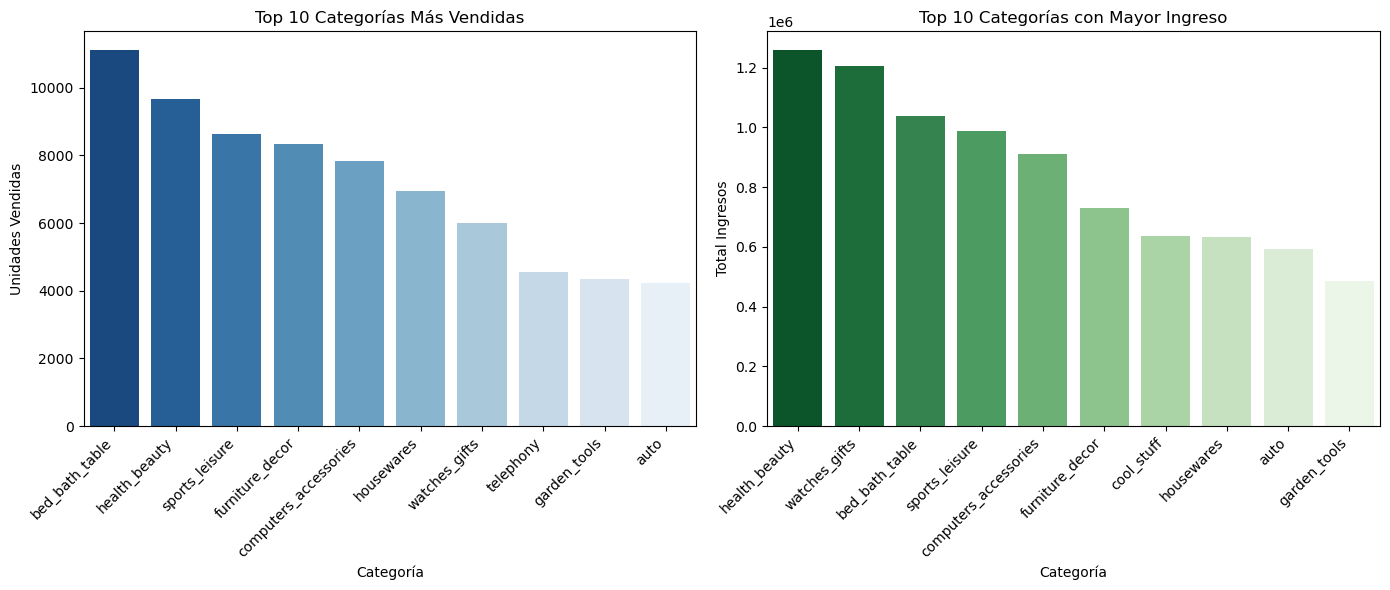

In [25]:
df_categorias_mas_ingresos = ejecutar_query_desde_archivo('queries/06_categorias_mas_ingresos.sql')
df_categorias_mas_vendidas = ejecutar_query_desde_archivo('queries/07_categorias_mas_vendidas.sql')

print("=== Top 10 categorías más vendidas ===")
print(
    df_categorias_mas_vendidas.to_string(
        index=False,
        formatters={"unidades_vendidas": "{:,.0f}".format}
    )
)

print("\n=== Top 10 categorías con mayor ingreso ===")
print(
    df_categorias_mas_ingresos.to_string(
        index=False,
        formatters={"total_ingresos_generados": "{:,.2f}".format}
    )
)
# Crear visualización comparativa
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Gráfico de categorías más vendidas
sns.barplot(x='categoria', y='unidades_vendidas', data=df_categorias_mas_vendidas, ax=ax1, palette='Blues_r')
ax1.set_title('Top 10 Categorías Más Vendidas', fontsize=12)
ax1.set_xlabel('Categoría')
ax1.set_ylabel('Unidades Vendidas')
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha='right')

# Gráfico de categorías con más ingresos
sns.barplot(x='categoria', y='total_ingresos_generados', data=df_categorias_mas_ingresos, ax=ax2, palette='Greens_r')
ax2.set_title('Top 10 Categorías con Mayor Ingreso', fontsize=12)
ax2.set_xlabel('Categoría')
ax2.set_ylabel('Total Ingresos')
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.show()



In [9]:
df_logistica_tiempos_estados = ejecutar_query_desde_archivo('queries/08_logistica_tiempos_estados.sql')

df_logistica_tiempos_estados

,estado,promedio_dias_anticipacion,maximo_retraso_historico_dias
0,AL,8.7,50
1,MA,9.6,134
2,SE,10.0,166
3,ES,10.5,181
4,CE,10.8,132
5,BA,10.8,138
6,SP,11.1,175
7,MS,11.1,29
8,PI,11.3,161
9,SC,11.5,69


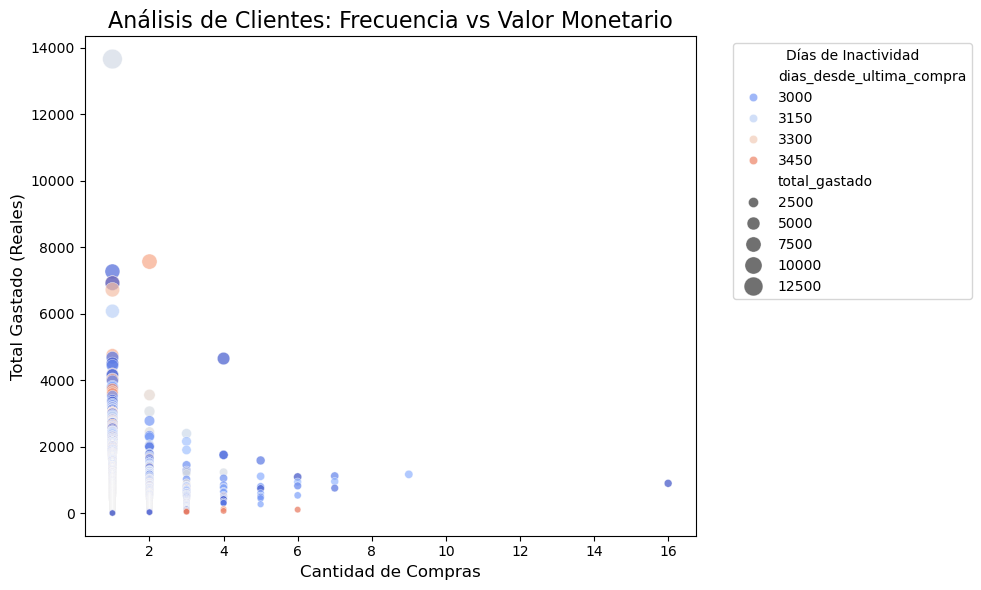

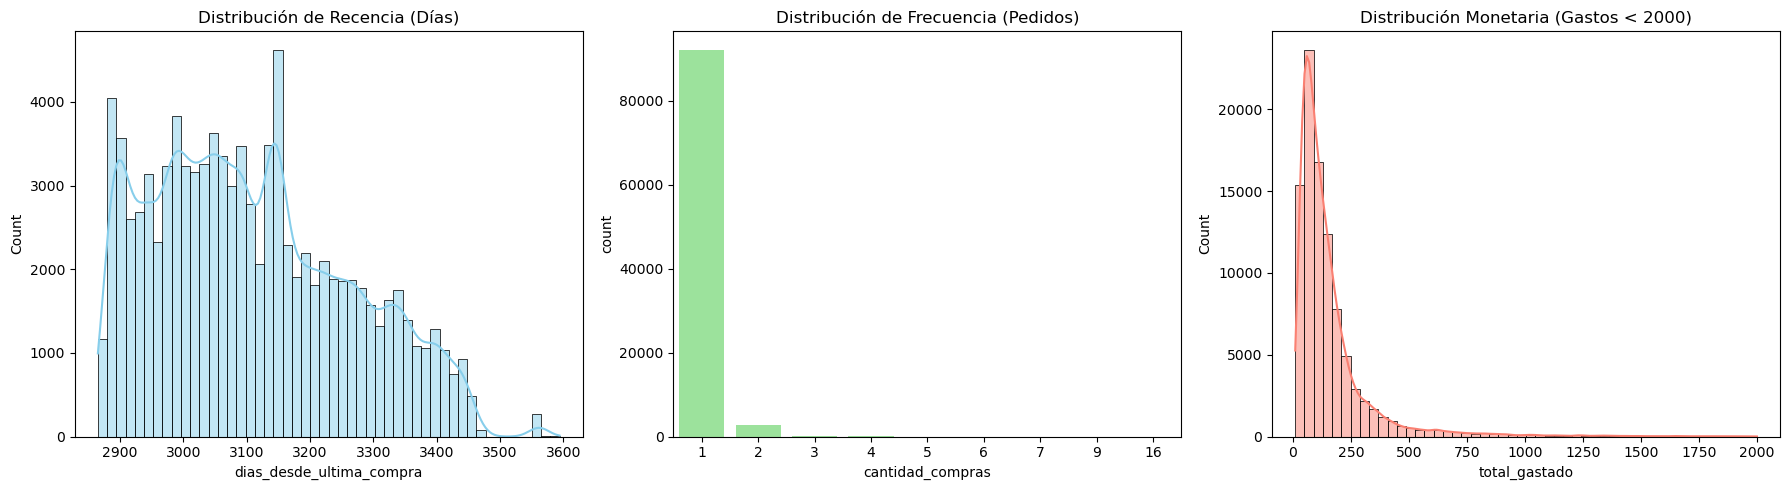

In [31]:
df_rfm = ejecutar_query_desde_archivo('queries/10_rfm.sql')

plt.figure(figsize=(10, 6))

scatter = sns.scatterplot(
    data=df_rfm, 
    x='cantidad_compras', 
    y='total_gastado', 
    hue='dias_desde_ultima_compra',
    palette='coolwarm',
    alpha=0.7,
    size='total_gastado',
    sizes=(20, 200)
)

plt.title('Análisis de Clientes: Frecuencia vs Valor Monetario', fontsize=16)
plt.xlabel('Cantidad de Compras', fontsize=12)
plt.ylabel('Total Gastado (Reales)', fontsize=12)
plt.legend(title='Días de Inactividad', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(df_rfm['dias_desde_ultima_compra'], bins=50, kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Distribución de Recencia (Días)')

sns.countplot(data=df_rfm, x='cantidad_compras', ax=axes[1], color='lightgreen')
axes[1].set_title('Distribución de Frecuencia (Pedidos)')

# Filtramos outliers extremos para que el gráfico sea legible
sns.histplot(df_rfm[df_rfm['total_gastado'] < 2000]['total_gastado'], bins=50, kde=True, ax=axes[2], color='salmon')
axes[2].set_title('Distribución Monetaria (Gastos < 2000)')

plt.tight_layout()
plt.show()


=== Resumen ===
Registros analizados: 96,353

Cantidad por estado del envío:
estado_envio
A Tiempo     89944
Retrasado     6409

Promedio de review_score por estado del envío:
estado_envio
A Tiempo     4.290
Retrasado    2.271

Promedio de días de anticipación por estado del envío:
estado_envio
A Tiempo     13.516
Retrasado   -10.527

Correlación entre días de anticipación y review_score:
0.2670


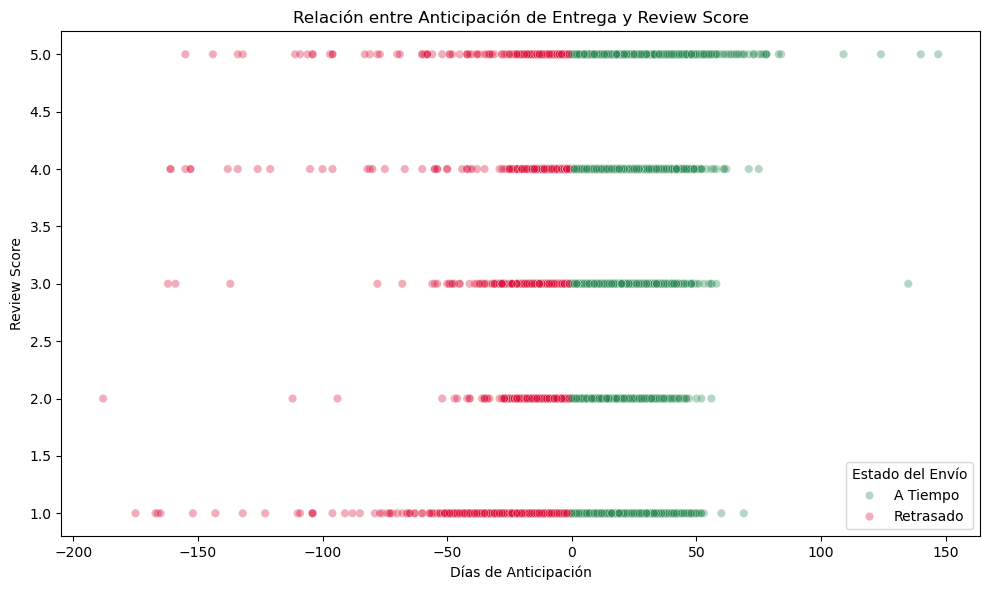

In [35]:
df_logistica_tiempos_indiv = ejecutar_query_desde_archivo('queries/09_logistica_tiempos_indiv.sql')
df_plot_logistica = df_logistica_tiempos_indiv.copy()

plt.figure(figsize=(10, 6))
df_plot_logistica['estado_envio'] = df_plot_logistica['dias_anticipacion'].apply(
    lambda x: 'Retrasado' if x < 0 else 'A Tiempo'
)

print("=== Resumen ===")
print(f"Registros analizados: {len(df_plot_logistica):,}")
print("\nCantidad por estado del envío:")
print(df_plot_logistica['estado_envio'].value_counts().to_string())

print("\nPromedio de review_score por estado del envío:")
print(
    df_plot_logistica.groupby('estado_envio')['review_score']
    .mean()
    .round(3)
    .to_string()
)

print("\nPromedio de días de anticipación por estado del envío:")
print(
    df_plot_logistica.groupby('estado_envio')['dias_anticipacion']
    .mean()
    .round(3)
    .to_string()
)

print("\nCorrelación entre días de anticipación y review_score:")
print(f"{df_plot_logistica[['dias_anticipacion', 'review_score']].corr().iloc[0, 1]:.4f}")

sns.scatterplot(
    data=df_plot_logistica,
    x='dias_anticipacion',
    y='review_score',
    hue='estado_envio',
    alpha=0.35,
    palette={'A Tiempo': 'seagreen', 'Retrasado': 'crimson'}
)

plt.title('Relación entre Anticipación de Entrega y Review Score')
plt.xlabel('Días de Anticipación')
plt.ylabel('Review Score')
plt.legend(title='Estado del Envío')
plt.tight_layout()
plt.show()

--- Impacto en el Review Score Promedio ---
estado_envio
A Tiempo     4.289980
Retrasado    2.271025
Name: review_score, dtype: float64

--- Distribución Porcentual de las Calificaciones ---
review_score          1        2          3          4          5
estado_envio                                                     
A Tiempo       6.627457  2.65165   8.076136  20.384906  62.259851
Retrasado     53.736932  8.67530  10.875332  10.173194  16.539242


/tmp/ipykernel_7349/2555206898.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='estado_envio', y='review_score', data=df_logistica_tiempos_indiv, palette='magma', errorbar=None)


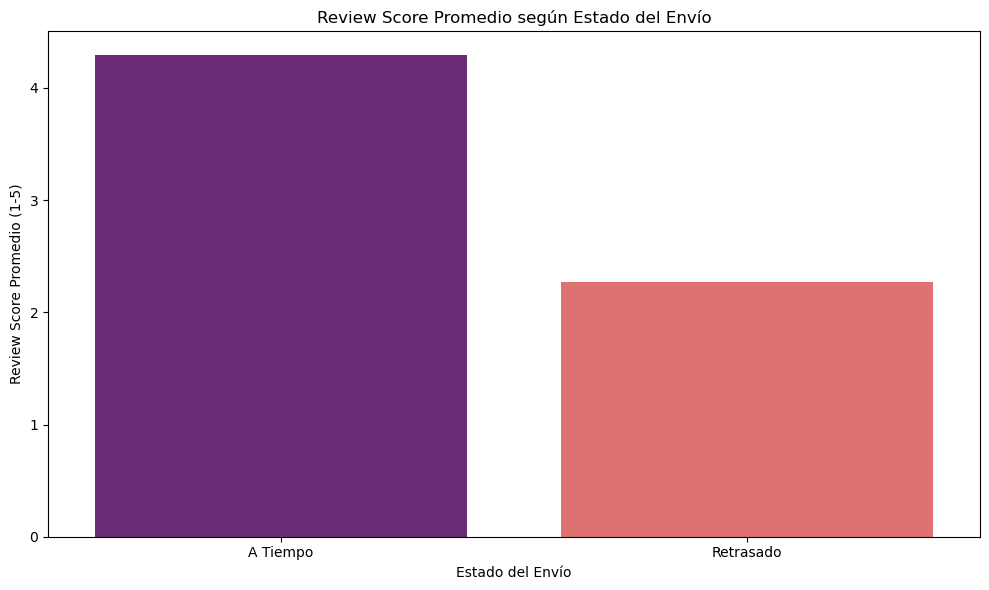

In [12]:
# Si los días de anticipación son menores a 0, el pedido se retrasó.
df_logistica_tiempos_indiv['estado_envio'] = df_logistica_tiempos_indiv['dias_anticipacion'].apply(
    lambda x: 'Retrasado' if x < 0 else 'A Tiempo'
)

print("--- Impacto en el Review Score Promedio ---")
print(df_logistica_tiempos_indiv.groupby('estado_envio')['review_score'].mean())

print("\n--- Distribución Porcentual de las Calificaciones ---")
print(pd.crosstab(df_logistica_tiempos_indiv['estado_envio'], df_logistica_tiempos_indiv['review_score'], normalize='index') * 100)

plt.figure(figsize=(10, 6))

# Gráfico de barras para comparar el Review Score promedio
sns.barplot(x='estado_envio', y='review_score', data=df_logistica_tiempos_indiv, palette='magma', errorbar=None)
plt.title('Review Score Promedio según Estado del Envío')
plt.xlabel('Estado del Envío')
plt.ylabel('Review Score Promedio (1-5)')

plt.tight_layout()
plt.show()

--- Matriz de Correlación de Pearson ---
                        precio  costo_del_transporte  peso_producto_gramos  \
precio                1.000000              0.414333              0.338819   
costo_del_transporte  0.414333              1.000000              0.610420   
peso_producto_gramos  0.338819              0.610420              1.000000   
volumen_producto_cm3  0.298754              0.587270              0.802267   

                      volumen_producto_cm3  
precio                            0.298754  
costo_del_transporte              0.587270  
peso_producto_gramos              0.802267  
volumen_producto_cm3              1.000000  


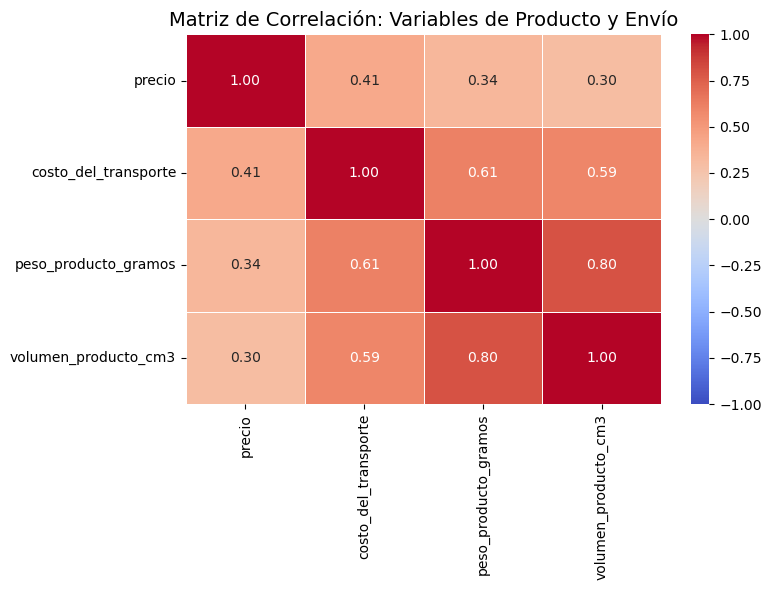

In [13]:
df_precio_envio_correlacion = ejecutar_query_desde_archivo('queries/11_precio_envio_correlacion.sql')

columnas_analisis = ['precio', 'costo_del_transporte', 'peso_producto_gramos', 'volumen_producto_cm3']
df_num = df_precio_envio_correlacion[columnas_analisis].dropna()

# Matriz de correlación
matriz_corr = df_num.corr(method='pearson')

print("--- Matriz de Correlación de Pearson ---")
print(matriz_corr)

plt.figure(figsize=(8, 6))

sns.heatmap(
    matriz_corr, 
    annot=True,
    cmap='coolwarm',
    fmt=".2f",
    linewidths=0.5,
    vmin=-1, vmax=1
)

plt.title('Matriz de Correlación: Variables de Producto y Envío', fontsize=14)
plt.tight_layout()
plt.show()

--- Diagnóstico de Pareto ---
El 80% de la facturación es generado por las primeras 16 categorías.
Esto equivale aproximadamente al 21.92% del catálogo total.


/tmp/ipykernel_7349/745387562.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='product_category_name', y='ingresos_categoria', data=df_top, ax=ax1, palette='Blues_r')
/tmp/ipykernel_7349/745387562.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha='right')


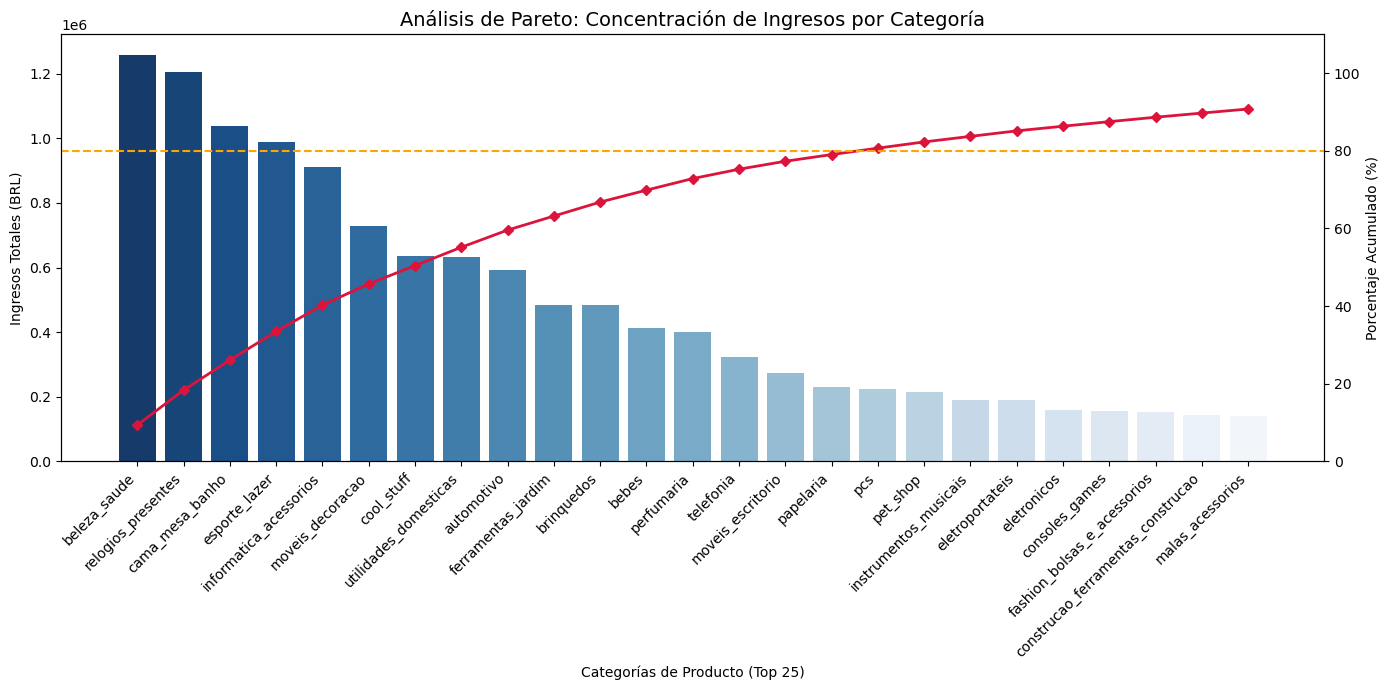

In [14]:
df_pareto = ejecutar_query_desde_archivo('queries/12_pareto.sql')
# Columna para saber qué porcentaje de las categorías representa cada fila
df_pareto['porcentaje_categorias'] = (pd.Series(range(1, len(df_pareto) + 1), index=df_pareto.index) / len(df_pareto)) * 100

# Punto donde se cruza el 80% de la facturación
punto_critico = df_pareto[df_pareto['porcentaje_acumulado'] <= 80].iloc[-1]

print(f"--- Diagnóstico de Pareto ---")
print(f"El 80% de la facturación es generado por las primeras {df_pareto[df_pareto['porcentaje_acumulado'] <= 80].shape[0]} categorías.")
print(f"Esto equivale aproximadamente al {punto_critico['porcentaje_categorias']:.2f}% del catálogo total.")

fig, ax1 = plt.subplots(figsize=(14, 7))

# Filtramos el top 25
df_top = df_pareto.head(25)

# Barras para los ingresos puros por categoría
sns.barplot(x='product_category_name', y='ingresos_categoria', data=df_top, ax=ax1, palette='Blues_r')
ax1.set_title('Análisis de Pareto: Concentración de Ingresos por Categoría', fontsize=14)
ax1.set_xlabel('Categorías de Producto (Top 25)')
ax1.set_ylabel('Ingresos Totales (BRL)')
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha='right')

ax2 = ax1.twinx()
ax2.plot(df_top['product_category_name'], df_top['porcentaje_acumulado'], color='crimson', marker='D', ms=5, linewidth=2)
ax2.set_ylabel('Porcentaje Acumulado (%)')
ax2.set_ylim(0, 110)

# La línea punteada del umbral del 80%
ax2.axhline(80, color='orange', linestyle='--', label='Umbral 80% Facturación')

plt.tight_layout()
plt.show()